In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

In [2]:
env = gym.make("CliffWalking-v1", is_slippery=True)
env.reset()

(36, {'prob': 1})

In [3]:
obs_dim = env.observation_space.n
act_dim = env.action_space.n

Q = np.zeros((obs_dim, act_dim))
Q.shape

(48, 4)

In [4]:
NUM_EPISODES = 100000
EPSILON = np.linspace(0.9, 0.1, NUM_EPISODES)
DISCOUNT = 0.9
ALPHA = 0.1

In [5]:
reward_history = []

for i, eps in enumerate(EPSILON):
    done = False
    total_reward = 0
    state, info = env.reset()
    action = np.argmax(Q[state]) if np.random.rand() > eps else env.action_space.sample()

    while not done:
        next_state, reward, terminated, truncated, info = env.step(action)
        next_action = np.argmax(Q[next_state]) if np.random.rand() > eps else env.action_space.sample()
        
        Q[state, action] += ALPHA * (
            reward + DISCOUNT * max(Q[next_state]) - Q[state, action]
        )

        total_reward += reward

        state = next_state
        action = next_action
        done = terminated or truncated

    reward_history.append(total_reward)

    if not (i + 1) % 100:
        print(f"Episode: {i+1}/{NUM_EPISODES}, Total reward: {total_reward}")

Episode: 100/100000, Total reward: -6990
Episode: 200/100000, Total reward: -3667
Episode: 300/100000, Total reward: -16854
Episode: 400/100000, Total reward: -32315
Episode: 500/100000, Total reward: -3311
Episode: 600/100000, Total reward: -24407
Episode: 700/100000, Total reward: -20079
Episode: 800/100000, Total reward: -6431
Episode: 900/100000, Total reward: -17270
Episode: 1000/100000, Total reward: -35762
Episode: 1100/100000, Total reward: -9751
Episode: 1200/100000, Total reward: -1710
Episode: 1300/100000, Total reward: -26716
Episode: 1400/100000, Total reward: -11057
Episode: 1500/100000, Total reward: -5921
Episode: 1600/100000, Total reward: -45984
Episode: 1700/100000, Total reward: -9433
Episode: 1800/100000, Total reward: -9392
Episode: 1900/100000, Total reward: -1369
Episode: 2000/100000, Total reward: -66494
Episode: 2100/100000, Total reward: -44391
Episode: 2200/100000, Total reward: -26593
Episode: 2300/100000, Total reward: -26883
Episode: 2400/100000, Total re

<function matplotlib.pyplot.show(close=None, block=None)>

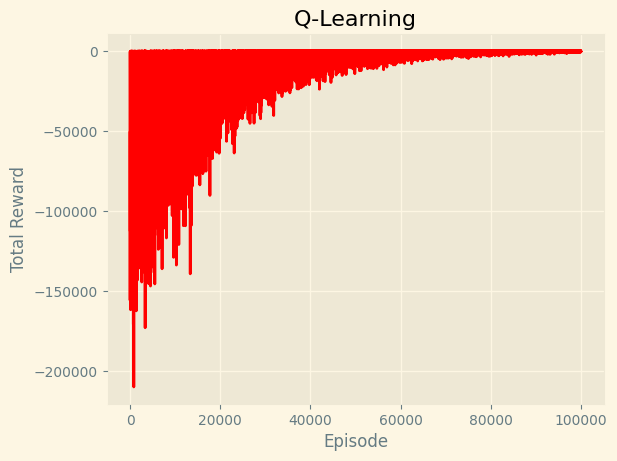

In [9]:
plt.style.use("Solarize_Light2")
plt.plot(reward_history, color="red")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Q-Learning")
plt.show

In [8]:
np.save('../experiments/qlearning_stochastic_rh.npy', reward_history)
np.save('../experiments/qlearning_stochastic_ag.npy', Q)